In [5]:
# import the library
from torchvision import datasets
import numpy as np
import cv2
import matplotlib.pyplot as plt
import sys
sys.path.append('../src')

from color_dg.color_spaces.converter import ColorspaceConverter


In [4]:
from torchvision import datasets
import numpy as np

# Load the  dataset CIFAR-10
dataset = datasets.CIFAR10(root='../data', train=True, download=True)

# Take the first image
image_pil, label = dataset[0] # image_pil: the first image in the dataset, label: the corresponding label (class index) for that image

# Convert to a NumPy array
image_rgb = np.array(image_pil)

print("Shape :", image_rgb.shape) # (32, 32, 3): image of 32x32 pixels with 3 color channels (RGB)
print("Type  :", image_rgb.dtype) # uint8: unsigned integer (0 to 255) for each color channel (Red, Green, Blue)
print("Classe:", dataset.classes[label])# frog: the label corresponds to the class "frog" in the CIFAR-10 dataset


Shape : (32, 32, 3)
Type  : uint8
Classe: frog


/home/stud/gnjinkap/miniforge3/envs/thesis/lib/python3.11/site-packages/torchvision/datasets/cifar.py:83: VisibleDeprecationWarning: dtype(): align should be passed as Python or NumPy boolean but got `align=0`. Did you mean to pass a tuple to create a subarray type? (Deprecated NumPy 2.4)
  entry = pickle.load(f, encoding="latin1")


In [6]:
# Apply the 3 conversions
image_hsv  = ColorspaceConverter.rgb_to_hsv(image_rgb) # Convert the RGB image to HSV color space using the ColorspaceConverter class. The resulting image_hsv will have the same shape as image_rgb but with different values representing the Hue, Saturation, and Value components of the colors.
image_lab  = ColorspaceConverter.rgb_to_lab(image_rgb) # Convert the RGB image to LAB color space using the ColorspaceConverter class. The resulting image_lab will have the same shape as image_rgb but with different values representing the Lightness, Red-Green, and Blue-Yellow components of the colors.
image_gray = ColorspaceConverter.rgb_to_grayscale(image_rgb)# Convert the RGB image to Grayscale using the ColorspaceConverter class. The resulting image_gray will have a shape of (32, 32) since it only contains intensity information without color channels.

# Also normalise the RGB values for display (same scale)
image_rgb_norm = image_rgb.astype(np.float32) / 255.0

print("HSV  shape:", image_hsv.shape,  "| min:", image_hsv.min().round(2),  "| max:", image_hsv.max().round(2))
print("LAB  shape:", image_lab.shape,  "| min:", image_lab.min().round(2),  "| max:", image_lab.max().round(2))
print("GRAY shape:", image_gray.shape, "| min:", image_gray.min().round(2), "| max:", image_gray.max().round(2))


HSV  shape: (32, 32, 3) | min: 0.0 | max: 1.0
LAB  shape: (32, 32, 3) | min: 0.0 | max: 0.99
GRAY shape: (32, 32, 3) | min: 0.0 | max: 0.98


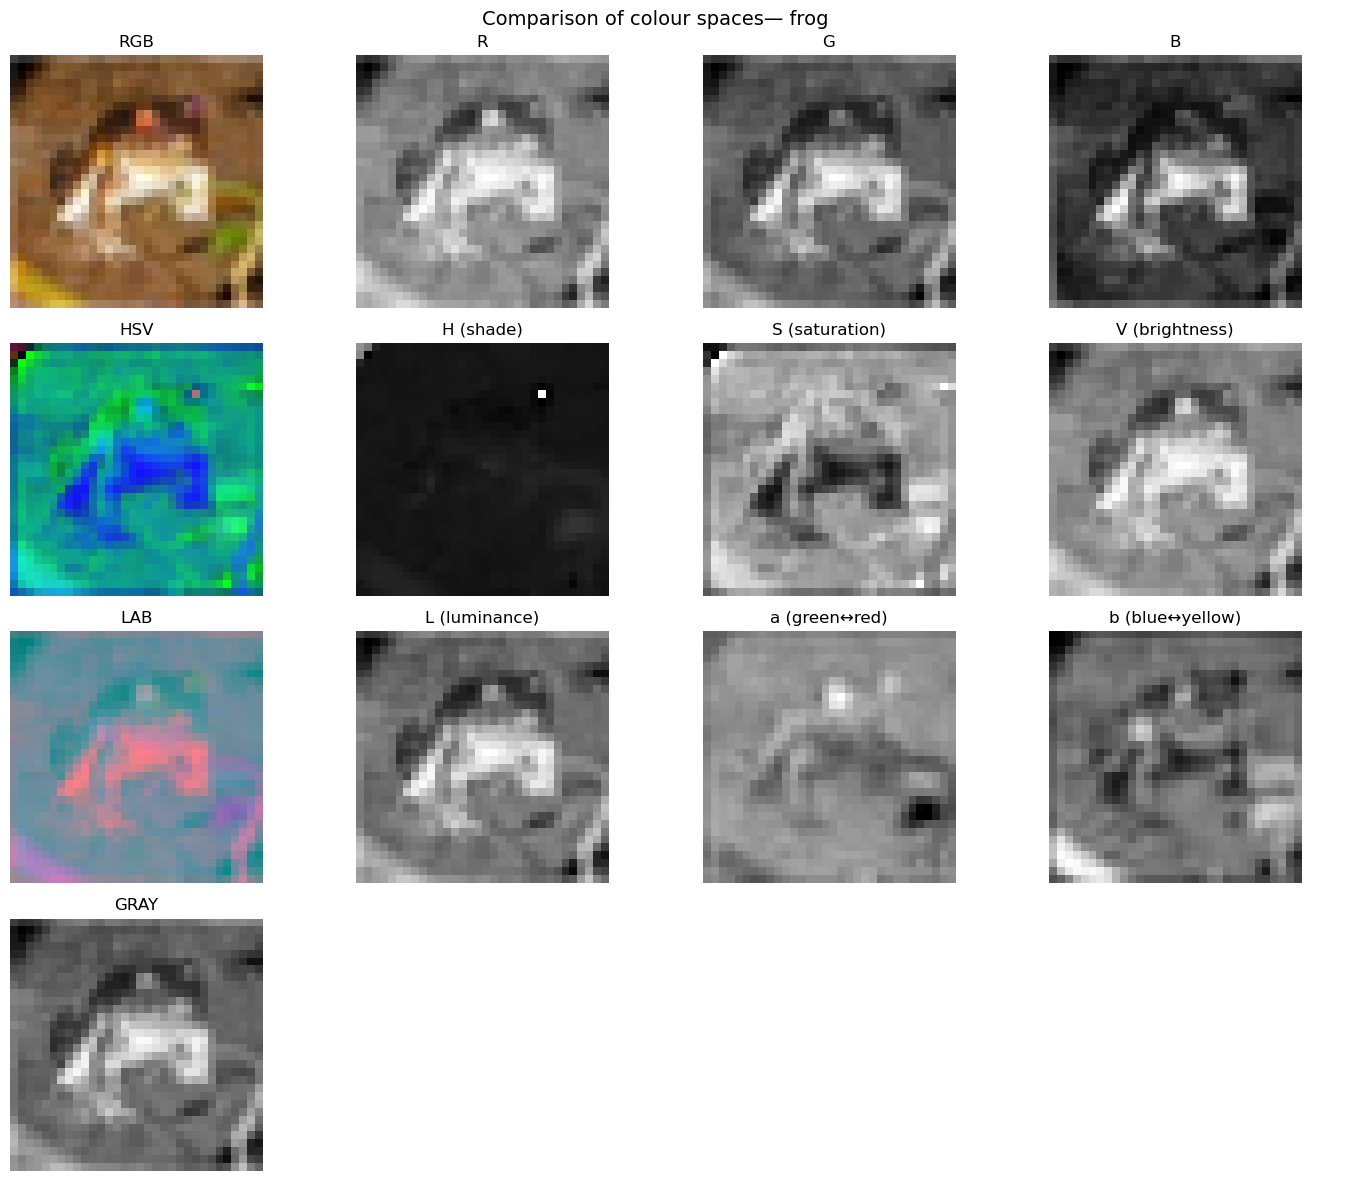

In [8]:
fig, axes = plt.subplots(4, 4, figsize=(14, 12))
fig.suptitle("Comparison of colour spaces— " + dataset.classes[label], fontsize=14)

name_rgb  = ["R", "G", "B"]
name_hsv  = ["H (shade)", "S (saturation)", "V (brightness)"]
name_lab  = ["L (luminance)", "a (green↔red)", "b (blue↔yellow)"]

lines = [
    (image_rgb_norm, "RGB",  name_rgb),
    (image_hsv,      "HSV",  name_hsv),
    (image_lab,      "LAB",  name_lab),
]

for i, (image, name, name_canaux) in enumerate(lines):
    # Full image
    axes[i, 0].imshow(image)
    axes[i, 0].set_title(name)
    axes[i, 0].axis('off')

    # The 3 channels separately
    for j in range(3):
        axes[i, j+1].imshow(image[:, :, j], cmap='gray')
        axes[i, j+1].set_title(name_canaux[j])
        axes[i, j+1].axis('off')

# Line 4 : Grayscale (one single image)
axes[3, 0].imshow(image_gray)
axes[3, 0].set_title("GRAY")
axes[3, 0].axis('off')
for j in range(1, 4):
    axes[3, j].axis('off')

plt.tight_layout()
plt.show()
